# Notebook 03 — Small Intestine Analysis

I subset to small intestine spots only and characterized:
1. Regional differences between Duodenum, Jejunum1, Jejunum2, Ileum
2. Villus layer differences (Crypt -> Bottom villous -> Top villous)
3. Whether villus layer identity differs across SI regions

This is the novel contribution extending Mayassi et al. 2024,
who focused primarily on colon regionalization.

## 1. Imports and Setup

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import psutil
import os
from upsetplot import UpSet, from_memberships


warnings.filterwarnings('ignore')
sc.settings.verbosity = 1

PROCESSED_DIR = "/home/wojmor/studies/MODEL/gut_project/data/processed"
FIGURES_DIR = "/home/wojmor/studies/MODEL/gut_project/results/figures"
TABLES_DIR = "/home/wojmor/studies/MODEL/gut_project/results/tables"

print("Imports done.")

Imports done.


## 2. Load Processed AnnData



In [2]:
adata = sc.read_h5ad(f"{PROCESSED_DIR}/visium_gut.h5ad")
print(adata)
print(f"\nobs columns: {adata.obs.columns.tolist()}")

AnnData object with n_obs × n_vars = 119892 × 32285
    obs: 'tissue_region', 'microbe', 'donor_id', 'biosample_id', 'sex', 'age', 'ylayer', 'tissue', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap', 'X_umap_paper', 'X_unroll'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

obs columns: ['tissue_region', 'microbe', 'donor_id', 'biosample_id', 'sex', 'age', 'ylayer', 'tissue', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'n_genes']


In [3]:
mem = psutil.virtual_memory()
print(f"Memory used: {mem.used / 1e9:.1f} GB")
print(f"Memory available: {mem.available / 1e9:.1f} GB")

Memory used: 11.7 GB
Memory available: 13.5 GB


## 3. Subset to Small Intestine

I focus on the four small intestine regions: Duodenum, Jejunum1, 
Jejunum2, and Ileum. Colon is excluded since the paper already 
analyzed it extensively.

In [4]:
# Subset to small intestine only
si_regions = ['Duodenum', 'Jejunum1', 'Jejunum2', 'Ileum']
adata_si = adata[adata.obs['tissue_region'].isin(si_regions)].copy()

print(f"Full dataset: {adata.n_obs} spots")
print(f"Small intestine only:  {adata_si.n_obs} spots")
print(f"\nSpots per region:")
print(adata_si.obs['tissue_region'].value_counts())
print(f"\nSpots per villus layer:")
print(adata_si.obs['ylayer'].value_counts())

Full dataset:          119892 spots
Small intestine only:  100878 spots

Spots per region:
tissue_region
Jejunum1    28781
Jejunum2    26198
Duodenum    24789
Ileum       21110
Name: count, dtype: int64

Spots per villus layer:
ylayer
Top villous SI       49367
Bottom villous SI    18754
Crypt SI             16462
Muscle SI            15781
Name: count, dtype: int64


In [5]:
mem = psutil.virtual_memory()
print(f"Memory used: {mem.used / 1e9:.1f} GB / available: {mem.available / 1e9:.1f} GB")

Memory used: 21.5 GB / available: 3.7 GB


In [6]:
# Free memory from full gut dataset - only si will be used in subsequent analyses
del adata
import gc
gc.collect()

1554

In [7]:
mem = psutil.virtual_memory()
print(f"Memory used: {mem.used / 1e9:.1f} GB / available: {mem.available / 1e9:.1f} GB")

Memory used: 10.4 GB / available: 14.8 GB


## 4. UMAP re-run on Small Intestine Only

Neighbor graph and UMAP were recomputed on SI spots only. This gives 
a cleaner embedding that focuses on SI-specific variation rather 
than being dominated by the colon vs SI difference.
PCA coordinates are already computed and stored in (`adata_si.obsm['X_pca']`)

In [8]:
sc.pp.neighbors(adata_si, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_si)

print("Neighbors and UMAP complete.")
print(f"UMAP shape: {adata_si.obsm['X_umap'].shape}")

Neighbors and UMAP complete.
UMAP shape: (100878, 2)


## 5. Small Intestine UMAP Visualisation

UMAP of small intestine spots only, colored by region and villus layer.



In [9]:
# Defining the same colors

REGION_COLORS = {
    'Duodenum':  '#1f77b4',
    'Jejunum1':  '#ff7f0e',
    'Jejunum2':  '#2ca02c',
    'Ileum':     '#d62728',
}

LAYER_COLORS = {
    'Top villous SI':    '#e41a1c',
    'Bottom villous SI': '#ff7f00',
    'Crypt SI':          '#4daf4a',
    'Muscle SI':         '#984ea3',
}

MICROBE_COLORS = {
    'SPF': '#2166ac',
    'GF':  '#d6604d',
    'FMT': '#4dac26',
}

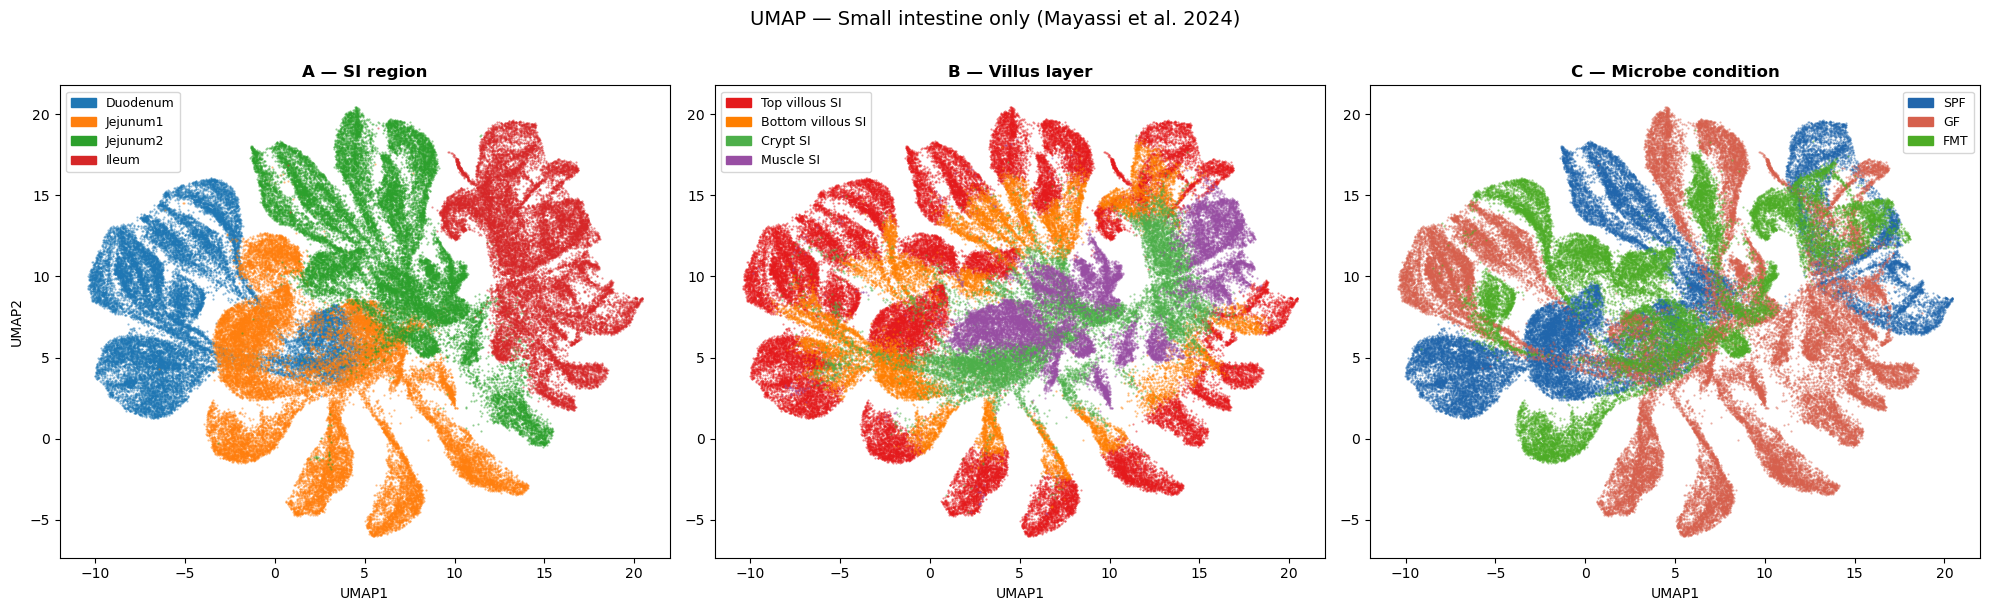

Figure 3 saved.


In [10]:
def make_legend(color_dict, ax, fontsize=9):
    patches = [mpatches.Patch(color=c, label=l)
               for l, c in color_dict.items()]
    ax.legend(handles=patches, fontsize=fontsize,
              markerscale=6, framealpha=0.8)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel A: by region
ax = axes[0]
for region, color in REGION_COLORS.items():
    mask = adata_si.obs['tissue_region'] == region
    ax.scatter(adata_si.obsm['X_umap'][mask, 0],
               adata_si.obsm['X_umap'][mask, 1],
               c=color, s=0.3, alpha=0.5, rasterized=True)
ax.set_title('A — SI region', fontweight='bold')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
make_legend(REGION_COLORS, ax)

# Panel B: by villus layer
ax = axes[1]
for layer, color in LAYER_COLORS.items():
    mask = adata_si.obs['ylayer'] == layer
    ax.scatter(adata_si.obsm['X_umap'][mask, 0],
               adata_si.obsm['X_umap'][mask, 1],
               c=color, s=0.3, alpha=0.5, rasterized=True)
ax.set_title('B — Villus layer', fontweight='bold')
ax.set_xlabel('UMAP1')
make_legend(LAYER_COLORS, ax)

# Panel C: by microbe condition
ax = axes[2]
for microbe, color in MICROBE_COLORS.items():
    mask = adata_si.obs['microbe'] == microbe
    ax.scatter(adata_si.obsm['X_umap'][mask, 0],
               adata_si.obsm['X_umap'][mask, 1],
               c=color, s=0.3, alpha=0.5, rasterized=True)
ax.set_title('C — Microbe condition', fontweight='bold')
ax.set_xlabel('UMAP1')
make_legend(MICROBE_COLORS, ax)

plt.suptitle('UMAP — Small intestine only (Mayassi et al. 2024)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_si_umap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Figure 3 saved.")

## 6. Leiden Clustering

Before DEG analysis using the existing region and layer labesl,
I run Leiden clustering, which finds groups of transcriptionally
similar spots without any prior labels.

Then I compare these clusters to our known annotations 
(region and villus layer) to validate them biologically.

**Resolutions tried:** 0.02, 0.05, 0.1, 0.25, 0.5

In [20]:
sc.tl.leiden(adata_si, resolution=0.5, key_added='leiden_05')       # resolution 0.5 chosen as a moderate setting

print("Leiden clustering complete.")
print(f"Number of clusters: {adata_si.obs['leiden_05'].nunique()}")
print(f"\nCluster sizes:")
print(adata_si.obs['leiden_05'].value_counts().sort_index())

Leiden clustering complete.
Number of clusters: 27

Cluster sizes:
leiden_05
0     10093
1      7122
2      6654
3      6367
4      6338
5      5824
6      4656
7      3551
8      3456
9      3310
10     3229
11     3219
12     2963
13     2962
14     2937
15     2920
16     2907
17     2830
18     2640
19     2635
20     2593
21     2577
22     2286
23     2250
24     1984
25     1741
26      834
Name: count, dtype: int64


## 7. Validate Clusters Against Known Annotations

I cross-reference Leiden clusters with tissue region and villus layer 
to see if the clustering captures real biological structure.

**Answer:** Partially

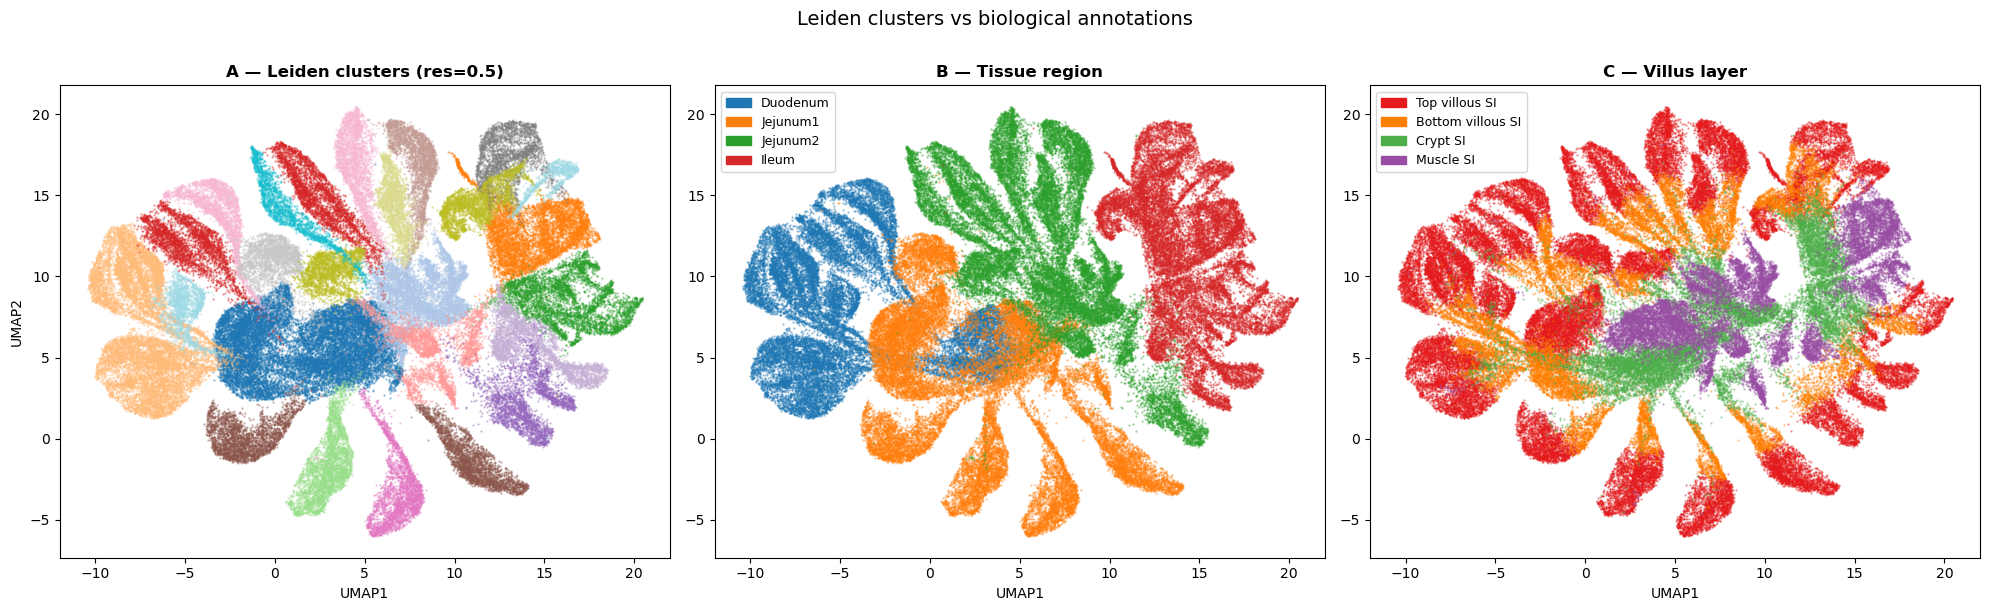

Figure saved.


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel A: Leiden clusters
ax = axes[0]
cluster_ids = adata_si.obs['leiden_05'].unique()
cmap = plt.cm.get_cmap('tab20', len(cluster_ids))
for i, cluster in enumerate(sorted(cluster_ids, key=int)):
    mask = adata_si.obs['leiden_05'] == cluster
    ax.scatter(adata_si.obsm['X_umap'][mask, 0],
               adata_si.obsm['X_umap'][mask, 1],
               c=[cmap(int(cluster))], s=0.3, alpha=0.5, 
               rasterized=True, label=cluster)
ax.set_title('A — Leiden clusters (res=0.5)', fontweight='bold')
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')

# Panel B: tissue region
ax = axes[1]
for region, color in REGION_COLORS.items():
    mask = adata_si.obs['tissue_region'] == region
    ax.scatter(adata_si.obsm['X_umap'][mask, 0],
               adata_si.obsm['X_umap'][mask, 1],
               c=color, s=0.3, alpha=0.5, rasterized=True)
ax.set_title('B — Tissue region', fontweight='bold')
ax.set_xlabel('UMAP1')
make_legend(REGION_COLORS, ax)

# Panel C: villus layer
ax = axes[2]
for layer, color in LAYER_COLORS.items():
    mask = adata_si.obs['ylayer'] == layer
    ax.scatter(adata_si.obsm['X_umap'][mask, 0],
               adata_si.obsm['X_umap'][mask, 1],
               c=color, s=0.3, alpha=0.5, rasterized=True)
ax.set_title('C — Villus layer', fontweight='bold')
ax.set_xlabel('UMAP1')
make_legend(LAYER_COLORS, ax)

plt.suptitle('Leiden clusters vs biological annotations',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_leiden_vs_annotations.png", 
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## 8. Cluster Composition Heatmap

Quantify the correspondence between Leiden clusters and 
our biological annotations using a normalized heatmap,
to show what fraction of each cluster's spots belong to 
each region/layer category.

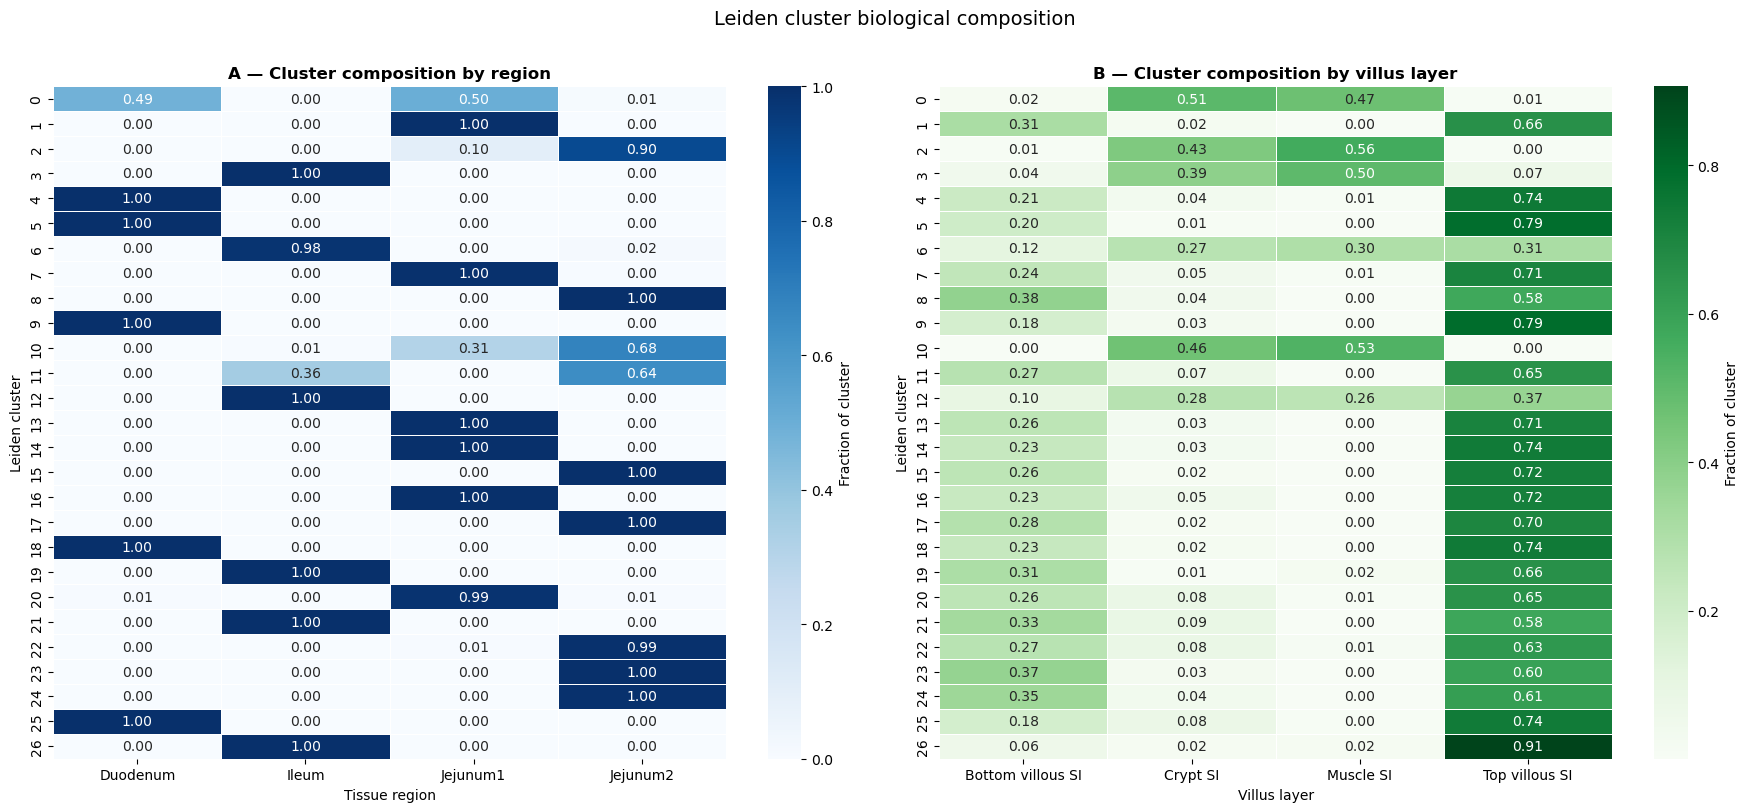

Figure saved.


In [22]:
# Cross-tabulate clusters vs region and layer
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Panel A: clusters vs tissue region
ct_region = pd.crosstab(
    adata_si.obs['leiden_05'],
    adata_si.obs['tissue_region'],
    normalize='index'  # normalize by row so each cluster sums to 1
)

sns.heatmap(ct_region, ax=axes[0], cmap='Blues',
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Fraction of cluster'})
axes[0].set_title('A — Cluster composition by region', fontweight='bold')
axes[0].set_xlabel('Tissue region')
axes[0].set_ylabel('Leiden cluster')

# Panel B: clusters vs villus layer
ct_layer = pd.crosstab(
    adata_si.obs['leiden_05'],
    adata_si.obs['ylayer'],
    normalize='index'
)

sns.heatmap(ct_layer, ax=axes[1], cmap='Greens',
            annot=True, fmt='.2f', linewidths=0.5,
            cbar_kws={'label': 'Fraction of cluster'})
axes[1].set_title('B — Cluster composition by villus layer', fontweight='bold')
axes[1].set_xlabel('Villus layer')
axes[1].set_ylabel('Leiden cluster')

plt.suptitle('Leiden cluster biological composition', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_cluster_composition_heatmap.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

Since the unsupervised Leiden clustering have not proven exceedingly succesfull, at least when it came to the crypt-villus tip axis (although severeal resolutions were tried) I used existing `tissue region` and `ylayer` annotation, provided by the authors directly for all subseuent analyses.

## 9. Differential Expression Analysis

I perform two DEG analyses:
1. **Between SI regions** (Duodenum vs Jejunum1 vs Jejunum2 vs Ileum)
2. **Between villus layers** (Crypt vs Bottom villous vs Top villous) 
   — characterizing the crypt-to-villus axis

I use Scanpy's Wilcoxon rank-sum test, which is robust and standard 
for spatial transcriptomics data. It is a non-parametric test used
for highly skewed, zero-inflated datasets.

THe comparison is "one vs rest", so foe reach group the test compares
spots in that group against all other spots combined.

**Significance tresholds:** adjusted p-value < 0.05 and |log2 fold change| > 0.5

### 9.1 DEGs Between SI Regions

In [13]:
# Set tissue_region as the grouping variable
adata_si.obs['tissue_region'] = adata_si.obs['tissue_region'].astype('category')

In [ ]:
# # Run rank genes groups - one vs rest for each region
sc.tl.rank_genes_groups(
    adata_si,
    groupby='tissue_region',
    method='wilcoxon',
    key_added='degs_region',
    pts=True                    # compute fraction of spots expressing each gene
)

print("DEG analysis between regions complete.")

DEG analysis between regions complete.


In [ ]:
# Display top DEGs for each region
print(sc.get.rank_genes_groups_df(
    adata_si,
    group=None,
    key='degs_region',
    pval_cutoff=0.05,
    log2fc_min=0.5
).head())

      group    names      scores  logfoldchanges  pvals  pvals_adj  \
0  Duodenum    S100g  228.002182      128.254547    0.0        0.0   
1  Duodenum     Reg1  224.392471      272.314026    0.0        0.0   
2  Duodenum  Sult6b2  200.467422       16.878366    0.0        0.0   
3  Duodenum   Papss2  199.242828       37.051315    0.0        0.0   
4  Duodenum   Slc4a7  179.989761       10.305953    0.0        0.0   

   pct_nz_group  pct_nz_reference  
0      0.981564          0.207494  
1      0.999274          0.454494  
2      0.897172          0.128468  
3      0.986930          0.717278  
4      0.901569          0.383801  


### 9.2 Extract and Save Region DEG Results

In [16]:
# Extract all significant DEGs
region_degs = sc.get.rank_genes_groups_df(
    adata_si,
    group=None,
    key='degs_region',
    pval_cutoff=0.05,
    log2fc_min=0.5
)

print(f"Total significant DEGs across all regions: {len(region_degs)}")
print(f"\nDEGs per region:")
print(region_degs.groupby('group').size())

# Save to file
region_degs.to_csv(f"{TABLES_DIR}/region_degs.csv", index=False)
print(f"\nSaved to results/tables/region_degs.csv")

Total significant DEGs across all regions: 6406

DEGs per region:
group
Duodenum    1929
Ileum       2801
Jejunum1    1075
Jejunum2     601
dtype: int64

Saved to results/tables/region_degs.csv


### 9.3  Top Region Markers — Dotplot


In [17]:
# Get top 5 markers per region
top_markers_region = (
    region_degs
    .groupby('group')
    .apply(lambda x: x.nlargest(5, 'scores'))
    .reset_index(drop=True)
)

marker_genes_region = top_markers_region['names'].tolist()

print("Top 5 markers per region:")
print(top_markers_region[['group', 'names', 'logfoldchanges', 'pvals_adj']])

Top 5 markers per region:
       group    names  logfoldchanges  pvals_adj
0   Duodenum    S100g      128.254547        0.0
1   Duodenum     Reg1      272.314026        0.0
2   Duodenum  Sult6b2       16.878366        0.0
3   Duodenum   Papss2       37.051315        0.0
4   Duodenum   Slc4a7       10.305953        0.0
5      Ileum    Fabp6             inf        0.0
6      Ileum   Tmigd1       25.598331        0.0
7      Ileum     Suox        7.371166        0.0
8      Ileum   Defa22      117.728683        0.0
9      Ileum    Reg3b       82.342026        0.0
10  Jejunum1     Adh1       14.016723        0.0
11  Jejunum1   Dnase1       12.314853        0.0
12  Jejunum1      Ace       33.252804        0.0
13  Jejunum1    Fabp1      241.882431        0.0
14  Jejunum1    Apoa4      168.356735        0.0
15  Jejunum2     Plb1        5.984626        0.0
16  Jejunum2   Defa21       22.589973        0.0
17  Jejunum2   Defa22       12.997924        0.0
18  Jejunum2  Fam151a        2.745123      

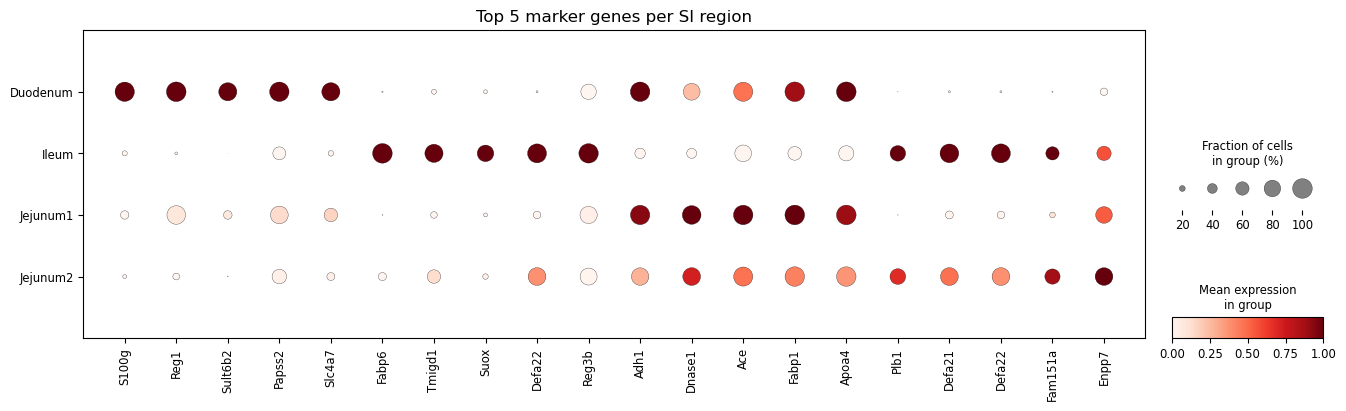

Dotplot saved.


In [18]:
sc.pl.dotplot(
    adata_si,
    var_names=marker_genes_region,
    groupby='tissue_region',
    standard_scale='var',  # scale each gene 0-1 for visibility
    save='03_region_marker_dotplot.png',
    title='Top 5 marker genes per SI region',
    figsize=(16, 4)
)
print("Dotplot saved.")

### 9.4 DEGs Between Villus Layers
Muscle SI is excluded as it's not part of the epithelial gradient.

In [19]:
# Subset to epithelial layers only (exclude Muscle SI)
epi_layers = ['Crypt SI', 'Bottom villous SI', 'Top villous SI']
adata_epi = adata_si[adata_si.obs['ylayer'].isin(epi_layers)].copy()

print(f"Epithelial spots: {adata_epi.n_obs}")
print(f"\nSpots per layer:")
print(adata_epi.obs['ylayer'].value_counts())

Epithelial spots: 84583

Spots per layer:
ylayer
Top villous SI       49367
Bottom villous SI    18754
Crypt SI             16462
Name: count, dtype: int64


In [20]:
# Set layer as category
adata_epi.obs['ylayer'] = adata_epi.obs['ylayer'].astype('category')

# Run DEG between villus layers
sc.tl.rank_genes_groups(
    adata_epi,
    groupby='ylayer',
    method='wilcoxon',
    key_added='degs_layer',
    pts=True
)

print("DEG analysis between villus layers complete.")

DEG analysis between villus layers complete.


In [21]:
# Extract layer DEGs
layer_degs = sc.get.rank_genes_groups_df(
    adata_epi,
    group=None,
    key='degs_layer',
    pval_cutoff=0.05,
    log2fc_min=0.5
)

print(f"Total significant DEGs across villus layers: {len(layer_degs)}")
print(f"\nDEGs per layer:")
print(layer_degs.groupby('group').size())
print(f"\nTop 5 Crypt SI markers:")
print(layer_degs[layer_degs['group']=='Crypt SI'].head())

# Save
layer_degs.to_csv(f"{TABLES_DIR}/layer_degs.csv", index=False)
print("\nSaved to results/tables/layer_degs.csv")

Total significant DEGs across villus layers: 8870

DEGs per layer:
group
Bottom villous SI    3245
Crypt SI             1312
Top villous SI       4313
dtype: int64

Top 5 Crypt SI markers:
         group    names     scores  logfoldchanges  pvals  pvals_adj  \
3245  Crypt SI    Kcne3  80.020966        2.987149    0.0        0.0   
3246  Crypt SI  Slc12a2  79.352493        2.912134    0.0        0.0   
3247  Crypt SI    Mki67  78.224525        2.820036    0.0        0.0   
3248  Crypt SI    Stmn1  77.803909        4.308489    0.0        0.0   
3249  Crypt SI    Olfm4  66.340134        8.601855    0.0        0.0   

      pct_nz_group  pct_nz_reference  
3245      0.625258          0.301053  
3246      0.737456          0.492506  
3247      0.606548          0.284861  
3248      0.731199          0.524596  
3249      0.857308          0.799871  

Saved to results/tables/layer_degs.csv


### 9.5 Top Villus Layer Markers — Dotplot

In [22]:
# Get top 5 markers per layer
top_markers_layer = (
    layer_degs
    .groupby('group')
    .apply(lambda x: x.nlargest(5, 'scores'))
    .reset_index(drop=True)
)

marker_genes_layer = top_markers_layer['names'].tolist()

print("Top 5 markers per villus layer:")
print(top_markers_layer[['group', 'names', 'logfoldchanges', 'pvals_adj']])

Top 5 markers per villus layer:
                group    names  logfoldchanges  pvals_adj
0   Bottom villous SI    Ccl25       34.605991        0.0
1   Bottom villous SI   Atpif1       59.627445        0.0
2   Bottom villous SI    Tstd1        9.296432        0.0
3   Bottom villous SI    Mgst1       15.830448        0.0
4   Bottom villous SI    Mtch2       16.248297        0.0
5            Crypt SI    Kcne3        2.987149        0.0
6            Crypt SI  Slc12a2        2.912134        0.0
7            Crypt SI    Mki67        2.820036        0.0
8            Crypt SI    Stmn1        4.308489        0.0
9            Crypt SI    Olfm4        8.601855        0.0
10     Top villous SI  Selenop      163.467484        0.0
11     Top villous SI     Klf4        8.567491        0.0
12     Top villous SI   mt-Co2      172.072296        0.0
13     Top villous SI   Clca4b       36.257267        0.0
14     Top villous SI     Apob       20.257242        0.0


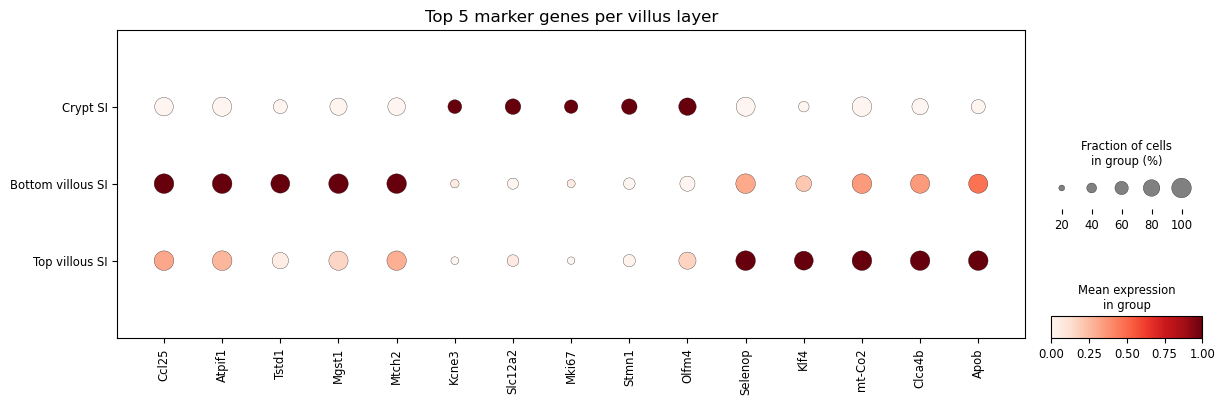

Dotplot saved.


In [23]:
# Order layers from crypt to tip
layer_order = ['Crypt SI', 'Bottom villous SI', 'Top villous SI']

sc.pl.dotplot(
    adata_epi,
    var_names=marker_genes_layer,
    groupby='ylayer',
    categories_order=layer_order,
    standard_scale='var',
    save='03_layer_marker_dotplot.png',
    title='Top 5 marker genes per villus layer',
    figsize=(14, 4)
)
print("Dotplot saved.")

## 10. Cross-Regional Consistency of Villus Layer Identity

This is what I wanted to be the central finding of this project.
I test this by running layer DEG analysis separately within 
each SI region and comparing the results. So, there are four 
anayses. Each of them compares crypt, bottom villus and villus tip 
within a single region. Then I compare overlaps.

In [24]:
# Run layer DEG separately within each SI region
results = {}

for region in ['Duodenum', 'Jejunum1', 'Jejunum2', 'Ileum']:
    # Subset to this region, epithelial layers only
    mask = (adata_si.obs['tissue_region'] == region) & \
           (adata_si.obs['ylayer'].isin(epi_layers))
    adata_reg = adata_si[mask].copy()
    
    # Run DEG
    sc.tl.rank_genes_groups(
        adata_reg,
        groupby='ylayer',
        method='wilcoxon',
        key_added='degs_layer',
        pts=True
    )
    
    # Extract results
    df = sc.get.rank_genes_groups_df(
        adata_reg,
        group=None,
        key='degs_layer',
        pval_cutoff=0.05,
        log2fc_min=0.5
    )
    df['region'] = region
    results[region] = df
    
    print(f"{region}: {len(df)} significant DEGs across layers")

# Combine all results
all_layer_degs = pd.concat(results.values(), ignore_index=True)
all_layer_degs.to_csv(f"{TABLES_DIR}/layer_degs_per_region.csv", index=False)
print(f"\nTotal DEGs saved: {len(all_layer_degs)}")

Duodenum: 8084 significant DEGs across layers
Jejunum1: 7752 significant DEGs across layers
Jejunum2: 8479 significant DEGs across layers
Ileum: 9676 significant DEGs across layers

Total DEGs saved: 33991


In [25]:
mem = psutil.virtual_memory()
print(f"Memory used: {mem.used / 1e9:.1f} GB / available: {mem.available / 1e9:.1f} GB")

Memory used: 24.3 GB / available: 0.9 GB


In [ ]:
# Delete the per-region adata objects from the loop
del adata_epi
gc.collect()


mem = psutil.virtual_memory()
print(f"Memory used: {mem.used / 1e9:.1f} GB / available: {mem.available / 1e9:.1f} GB")

Memory used: 8.9 GB / available: 16.3 GB


## 11. Overlap Analysis — Is the Villus Layer Program Conserved?

For each villus layer I have four marker gene (just genes that are DEGs for this particular region) sets — one per SI region. I compute how many genes from these four sets are shared across all four SI regions. Those that are shared by all the regions in a given layer I consider the conserved core. Genes that are markers in only some regions (especially only one region) I consider region-specific.

In [27]:
# For each layer, find genes that are significant markers in each region
for layer in epi_layers:
    print(f"\n--- {layer} ---")
    
    # Get marker genes for this layer in each region
    gene_sets = {}
    for region in ['Duodenum', 'Jejunum1', 'Jejunum2', 'Ileum']:
        mask = (all_layer_degs['group'] == layer) & \
               (all_layer_degs['region'] == region)
        gene_sets[region] = set(all_layer_degs[mask]['names'])
        print(f"  {region}: {len(gene_sets[region])} markers")
    
    # Find genes shared across ALL four regions
    shared_all = gene_sets['Duodenum'] & gene_sets['Jejunum1'] & \
                 gene_sets['Jejunum2'] & gene_sets['Ileum']
    print(f"  Shared across ALL 4 regions: {len(shared_all)}")
    print(f"  Examples: {list(shared_all)[:10]}")


--- Crypt SI ---
  Duodenum: 1146 markers
  Jejunum1: 1364 markers
  Jejunum2: 869 markers
  Ileum: 786 markers
  Shared across ALL 4 regions: 646
  Examples: ['Gpam', 'Vars2', 'Paip2b', 'Pkp1', 'Mcm6', 'Pask', 'Bub1b', 'Cdo1', 'Haus5', 'Nup155']

--- Bottom villous SI ---
  Duodenum: 3631 markers
  Jejunum1: 3427 markers
  Jejunum2: 2668 markers
  Ileum: 3580 markers
  Shared across ALL 4 regions: 2224
  Examples: ['Slc51b', 'Rpl19', 'Aldh9a1', 'March6', 'Ech1', 'Igkc', 'Commd3', 'Ces2g', 'Gpx1', 'Ywhaq']

--- Top villous SI ---
  Duodenum: 3307 markers
  Jejunum1: 2961 markers
  Jejunum2: 4942 markers
  Ileum: 5310 markers
  Shared across ALL 4 regions: 2381
  Examples: ['Ptger4', 'Slc6a8', 'Vamp3', 'March6', 'Maf1', 'Klf16', 'Zbp1', 'Spon1', 'Itfg1', 'Rcan1']


## 12. Figure — Overlap of Layer Markers Across SI Regions

Visualize how many villus layer marker genes are shared across SI regions as a bar charts.


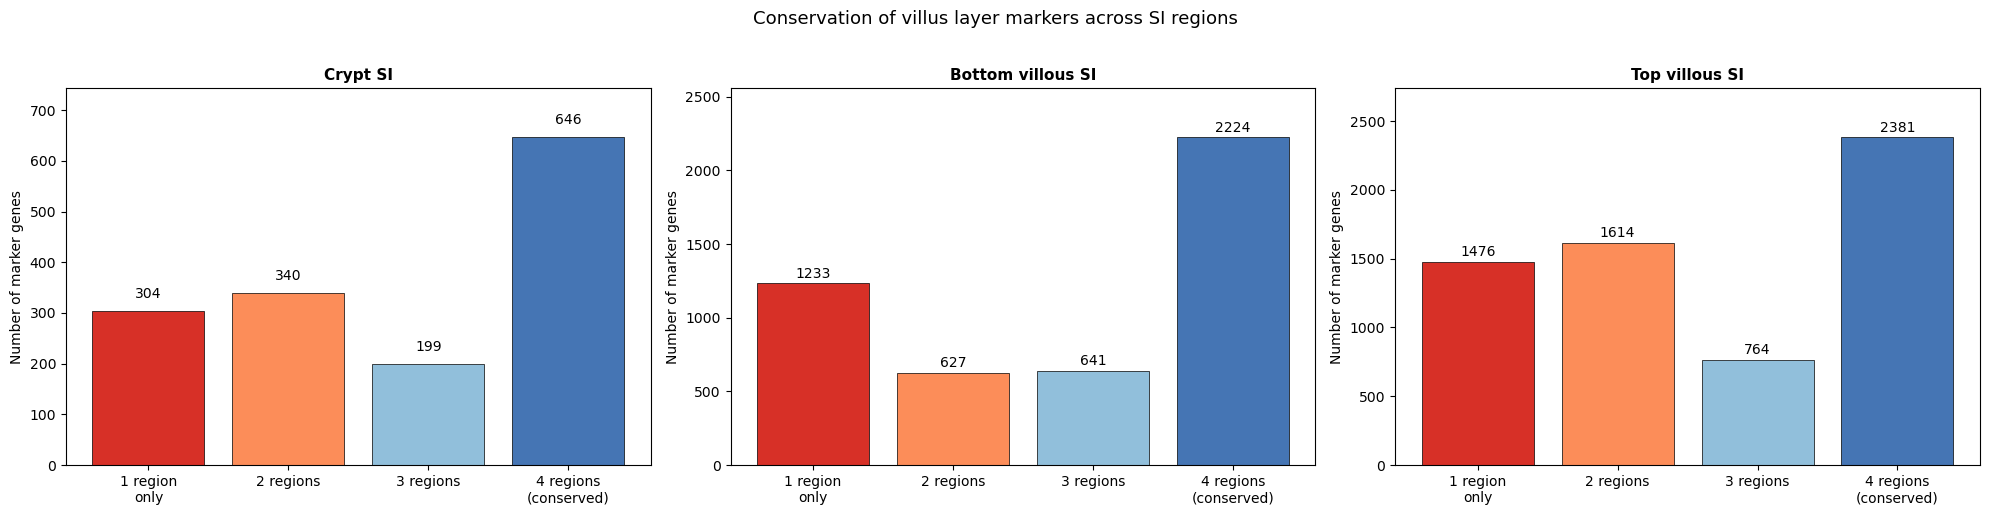

Figure saved.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

regions = ['Duodenum', 'Jejunum1', 'Jejunum2', 'Ileum']

for ax_idx, layer in enumerate(epi_layers):
    # Get gene sets per region for this layer
    gene_sets = {}
    for region in regions:
        mask = (all_layer_degs['group'] == layer) & \
               (all_layer_degs['region'] == region)
        gene_sets[region] = set(all_layer_degs[mask]['names'])
    
    # Calculate overlap sizes for a simple bar chart
    all_genes = set.union(*gene_sets.values())
    
    # Count how many regions each gene appears in
    gene_counts = {}
    for gene in all_genes:
        count = sum(1 for r in regions if gene in gene_sets[r])
        gene_counts[count] = gene_counts.get(count, 0) + 1
    
    # Plot
    ax = axes[ax_idx]
    bars = ax.bar(
        ['1 region\nonly', '2 regions', '3 regions', '4 regions\n(conserved)'],
        [gene_counts.get(i, 0) for i in range(1, 5)],
        color=['#d73027', '#fc8d59', '#91bfdb', '#4575b4'],
        edgecolor='black', linewidth=0.5
    )
    
    # Add counts on bars
    for bar, count in zip(bars, [gene_counts.get(i, 0) for i in range(1, 5)]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(count), ha='center', va='bottom', fontsize=10)
    
    ax.set_title(f'{layer}', fontweight='bold', fontsize=11)
    ax.set_ylabel('Number of marker genes')
    ax.set_ylim(0, max(gene_counts.values()) * 1.15)

plt.suptitle('Conservation of villus layer markers across SI regions',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_layer_marker_conservation.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")

## 13. Conserved Core Genes — Biological Interpretation

I now look at the conserved top villous markers — genes expressed 
at the villus tip across all four SI segments.

In [ ]:
# Get conserved top villous genes across all 4 regions
gene_sets_top = {}
for region in regions:
    mask = (all_layer_degs['group'] == 'Top villous SI') & \
           (all_layer_degs['region'] == region)
    gene_sets_top[region] = set(all_layer_degs[mask]['names'])

# Genes that are top villus markers in all four regions
conserved_top_villous = gene_sets_top['Duodenum'] & \
                         gene_sets_top['Jejunum1'] & \
                         gene_sets_top['Jejunum2'] & \
                         gene_sets_top['Ileum']

# Get scores for conserved genes from the full layer DEG analysis
conserved_top_df = layer_degs[
    (layer_degs['group'] == 'Top villous SI') &
    (layer_degs['names'].isin(conserved_top_villous))
].sort_values('scores', ascending=False)                    # sort by score to get most significant markers at the top

print(f"Conserved top villous genes: {len(conserved_top_villous)}")
print(f"\nTop 20 conserved villus tip markers:")
print(conserved_top_df[['names', 'logfoldchanges', 'pvals_adj']].head(20))

Conserved top villous genes: 2381

Top 20 conserved villus tip markers:
        names  logfoldchanges  pvals_adj
4557  Selenop      163.467484        0.0
4558     Klf4        8.567491        0.0
4559   mt-Co2      172.072296        0.0
4560   Clca4b       36.257267        0.0
4561     Apob       20.257242        0.0
4562    H2-K1       48.556931        0.0
4563  Slc6a19       21.332457        0.0
4564    Cdhr2       18.824337        0.0
4565   mt-Nd4       61.238220        0.0
4566      B2m       72.963158        0.0
4567   mt-Nd1       55.623772        0.0
4568   mt-Co3      335.563507        0.0
4569   mt-Nd3       22.734470        0.0
4570  mt-Atp6      230.709686        0.0
4571     Mxd1        7.443334        0.0
4572   mt-Nd2       29.225189        0.0
4573    Enpp3       15.002264        0.0
4574     Bst1        9.526283        0.0
4575    H2-D1       17.395708        0.0
4576   Slc6a8       10.698797        0.0


### 13.1 Filtering out mitochondrial genes
Mitochondrial genes (with prefix `mt-`) were excluded from marker visualization as they reflect cellular energy demand rather than specific functional identity and were dominant across all parts of the villi.

In [ ]:
# Filter out mitochondrial genes
conserved_top_df_nmt = conserved_top_df[
    ~conserved_top_df['names'].str.startswith('mt-')
]

top_conserved_genes_nmt = conserved_top_df_nmt['names'].head(15).tolist()
print("Top 15 conserved tip markers (excluding mitochondrial):")
print(top_conserved_genes_nmt)

Top 15 conserved tip markers (excluding mitochondrial):
['Selenop', 'Klf4', 'Clca4b', 'Apob', 'H2-K1', 'Slc6a19', 'Cdhr2', 'B2m', 'Mxd1', 'Enpp3', 'Bst1', 'H2-D1', 'Slc6a8', 'Muc3', 'Hsd17b11']


## 14. Figure — Conserved Villus Tip Markers Heatmap

For each of the top 15 conserved tip marker genes, I computed mean expression inn every region x layer combination and visualised it as a heatmap.
These genes, in principle, should represent the transcriptional identity of mature absorptive enterocytes.

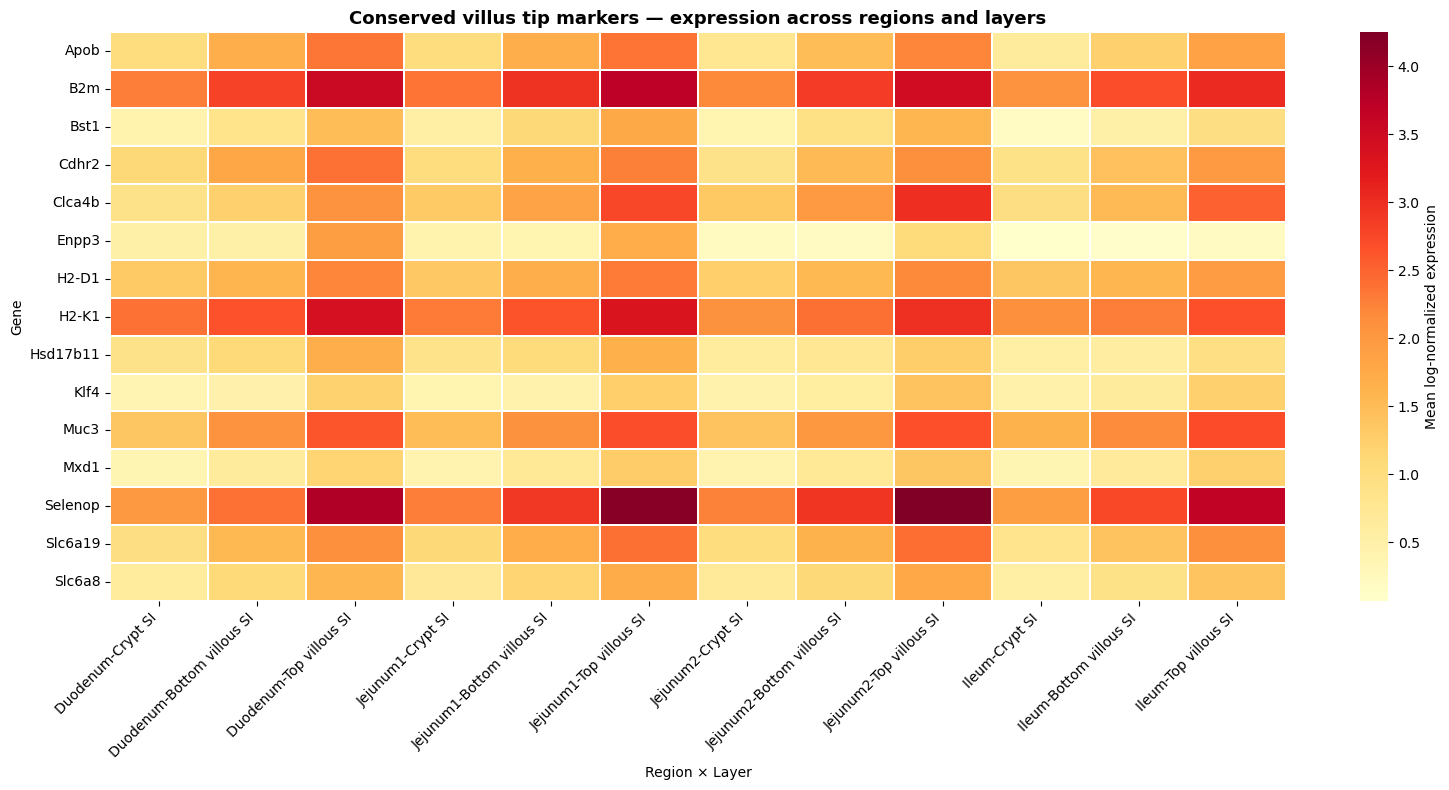

Figure saved.


In [ ]:

# Create a summary matrix: mean expression per region × layer combination
adata_epi2 = adata_si[adata_si.obs['ylayer'].isin(epi_layers)].copy()

# Build mean expression dataframe
records = []
for region in regions:
    for layer in layer_order:
        mask = ((adata_epi2.obs['tissue_region'] == region) &
                (adata_epi2.obs['ylayer'] == layer)).values
        if mask.sum() == 0:
            continue
        gene_idx = [list(adata_epi2.var_names).index(g) 
                    for g in top_conserved_genes_nmt 
                    if g in adata_epi2.var_names]
        expr = np.asarray(
            adata_epi2.X[mask][:, gene_idx].mean(axis=0)
        ).flatten()
        for gene, val in zip(top_conserved_genes_nmt, expr):
            records.append({
                'region': region,
                'layer': layer,
                'gene': gene,
                'mean_expr': val
            })

expr_df = pd.DataFrame(records)

# Pivot with correct biological order not alphabetical
correct_layer_order = ['Crypt SI', 'Bottom villous SI', 'Top villous SI']
correct_region_order = ['Duodenum', 'Jejunum1', 'Jejunum2', 'Ileum']

expr_pivot = expr_df.pivot_table(
    index='gene',
    columns=['region', 'layer'],
    values='mean_expr'
)

ordered_cols = [(region, layer)
                for region in correct_region_order
                for layer in correct_layer_order
                if (region, layer) in expr_pivot.columns]

expr_pivot = expr_pivot[ordered_cols]

# Plot
fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    expr_pivot,
    cmap='YlOrRd',
    ax=ax,
    linewidths=0.3,
    cbar_kws={'label': 'Mean log-normalized expression'}
)
ax.set_title('Conserved villus tip markers — expression across regions and layers',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Region × Layer')
ax.set_ylabel('Gene')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/03_conserved_tip_markers_heatmap.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved.")